# Aufgabe 2 – Confusion Matrix

Ein CNN wird auf dem HaGRID-Datensatz trainiert (Kategorien: `like`, `rock`, `peace`).
Danach werden Vorhersagen für die eigenen Bilder und die Tutor-Bilder gemacht
und als Confusion Matrix gespeichert.

In [1]:
import cv2
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, RandomFlip, RandomContrast
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
DATASET_PATH = '/Users/arne/Downloads/gesture_dataset_sample'
OWN_PATH     = os.path.dirname(os.path.abspath('confusion_matrix.ipynb'))
TUTOR_PATH   = os.path.join(OWN_PATH, 'tutor_images')

CATEGORIES = ['like', 'rock', 'peace']
IMG_SIZE   = 64

## Modell trainieren

In [3]:
def build_model(num_classes):
    model = Sequential([
        RandomFlip('horizontal'),
        RandomContrast(0.1),
        Conv2D(64, (9, 9), activation='leaky_relu', padding='same',
               input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        MaxPooling2D((4, 4), padding='same'),
        Conv2D(32, (5, 5), activation='leaky_relu', padding='same'),
        MaxPooling2D((3, 3), padding='same'),
        Conv2D(32, (3, 3), activation='leaky_relu', padding='same'),
        MaxPooling2D((2, 2), padding='same'),
        Dropout(0.2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax'),
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def load_training_data():
    images, labels = [], []
    for idx, cat in enumerate(CATEGORIES):
        with open(f'{DATASET_PATH}/_annotations/{cat}.json') as f:
            annotations = json.load(f)
        for filename in os.listdir(f'{DATASET_PATH}/{cat}'):
            uid = filename.split('.')[0]
            if uid not in annotations:
                continue
            img = cv2.imread(f'{DATASET_PATH}/{cat}/{filename}')
            if img is None:
                continue
            ann = annotations[uid]
            for i, bbox in enumerate(ann['bboxes']):
                if ann['labels'][i] != cat:
                    continue
                x1 = int(bbox[0] * img.shape[1])
                y1 = int(bbox[1] * img.shape[0])
                w  = int(bbox[2] * img.shape[1])
                h  = int(bbox[3] * img.shape[0])
                crop = img[y1:y1+h, x1:x1+w]
                if crop.size == 0:
                    continue
                images.append(cv2.resize(crop, (IMG_SIZE, IMG_SIZE)))
                labels.append(idx)
    return np.array(images), np.array(labels)


X, y = load_training_data()
X = X.astype('float32') / 255.0
y_oh = to_categorical(y, len(CATEGORIES))
X_train, X_test, y_train, y_test = train_test_split(X, y_oh, test_size=0.2, random_state=42)

model = build_model(len(CATEGORIES))
model.fit(
    X_train, y_train,
    batch_size=8, epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(patience=3), ReduceLROnPlateau(patience=2, min_lr=1e-4)],
    verbose=1
)

_, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test-Genauigkeit: {acc:.2%}')

Epoch 1/50


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 1/75 ━━━━━━━━━━━━━━━━━━━━ 1:28 1s/step - accuracy: 0.6250 - loss: 1.0603

 4/75 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4453 - loss: 1.1885

 7/75 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3950 - loss: 1.1803

...

67/75 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9958 - loss: 0.0353

70/75 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9957 - loss: 0.0359

73/75 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9955 - loss: 0.0365

75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9917 - loss: 0.0500 - val_accuracy: 0.9333 - val_loss: 0.1774 - learning_rate: 1.0000e-04


Test-Genauigkeit: 93.33%


## Vorhersagen auf eigenen + Tutor-Bildern

In [4]:
def predict_from_annotations(img_dir, ann_file):
    """Lädt Bilder anhand der Annotationen, croppt die Hand und gibt Vorhersagen zurück."""
    with open(ann_file) as f:
        annotations = json.load(f)

    true_labels, pred_labels = [], []

    for uid, ann in annotations.items():
        # Bilddatei suchen (jpg oder png)
        img_path = None
        for ext in ['jpg', 'jpeg', 'png']:
            candidate = os.path.join(img_dir, f'{uid}.{ext}')
            if os.path.exists(candidate):
                img_path = candidate
                break
        if img_path is None:
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue

        for i, bbox in enumerate(ann['bboxes']):
            label = ann['labels'][i]
            if label not in CATEGORIES:  # no_gesture überspringen
                continue

            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w  = int(bbox[2] * img.shape[1])
            h  = int(bbox[3] * img.shape[0])
            crop = img[y1:y1+h, x1:x1+w]
            if crop.size == 0:
                continue

            inp  = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))
            inp  = np.expand_dims(inp.astype('float32') / 255.0, 0)
            pred = CATEGORIES[int(np.argmax(model.predict(inp, verbose=0)[0]))]

            true_labels.append(label)
            pred_labels.append(pred)

    return true_labels, pred_labels


# eigene Bilder
true_own, pred_own = predict_from_annotations(OWN_PATH, os.path.join(OWN_PATH, 'annot-FArneH.json'))

# Tutor-Bilder
true_tutor, pred_tutor = predict_from_annotations(TUTOR_PATH, os.path.join(TUTOR_PATH, 'annot-tutors.json'))

# zusammenführen
true_all = true_own + true_tutor
pred_all = pred_own + pred_tutor

print('Wahre Labels:      ', true_all)
print('Vorhergesagte Labels:', pred_all)

Wahre Labels:       ['like', 'rock', 'peace', 'rock', 'peace', 'peace', 'like', 'like', 'rock']
Vorhergesagte Labels: ['like', 'rock', 'peace', 'rock', 'peace', 'peace', 'like', 'like', 'rock']


## Confusion Matrix

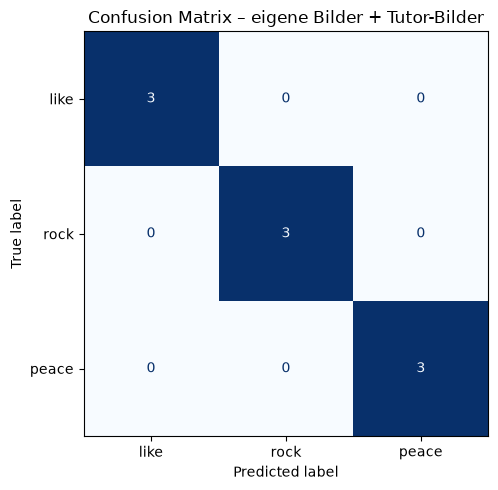

Gespeichert als conf-matrix.png


In [5]:
cm = confusion_matrix(true_all, pred_all, labels=CATEGORIES)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CATEGORIES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix – eigene Bilder + Tutor-Bilder')

plt.tight_layout()
plt.savefig('conf-matrix.png', dpi=150)
plt.show()
print('Gespeichert als conf-matrix.png')